In [1]:
%matplotlib notebook
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy

<IPython.core.display.Javascript object>


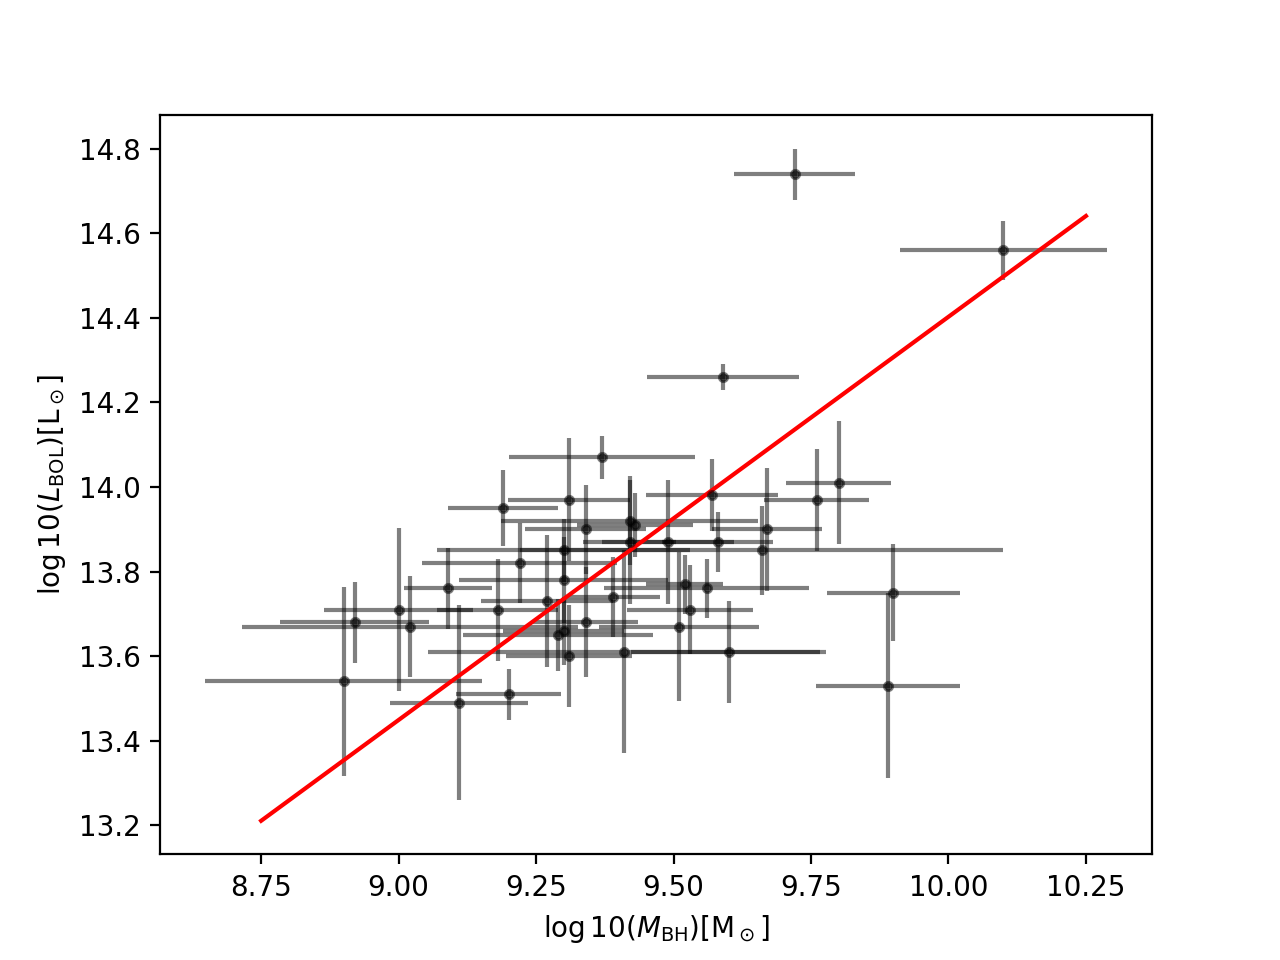

<ErrorbarContainer object of 3 artists>

In [2]:
d = np.loadtxt("LbolMbh2.dat",unpack=True)
lL = d[0]
lM = d[1]
slL = d[2]
slM = d[3]

fig, ax = plt.subplots()

ax.set_xlabel(r"$\log10(M_{\rm BH}) [{\rm M_\odot}]$")
ax.set_ylabel(r"$\log10(L_{\rm BOL}) [{\rm L_\odot}]$")

ax.errorbar(lM,lL,slL,slM,"k.",alpha=0.5)

In [3]:
from timeit import default_timer as timer # time all methods

#
# Choose a pivot point (to be played with in class)
#
lMcen = 0 #np.mean(lM)

#
# Function we integrate
#
def ifun(lM,t,lLi,lMi,slLi,slMi):
    '''
    Return p(lL,lM) function for the given model parametes times Gaussian for one data point
    Inputs: integration variables lL=log10(L), lM=log10(M)
            vector of parameters t
            data point: log10(L_i), log10(M_i), and their errors.
    '''
    lL = t[0]*(lM-lMcen) + t[1]
    v = np.exp(-0.5*(((lL-lLi)/slLi)**2+((lM-lMi)/slMi)**2))
    return v
#


#
# log-likelihood
#
def llfun(t,loud=True):
    '''
    Return -log(L) where L is the likelihood
    Inputs: vector of parameters t
            optional argument that toggles printing (useful for debugging)
    '''
    fact = 1/(2*np.pi)
    
    start_time = timer()
    ret = 0
    for i in range(len(lL)):
        lM1 = lM[i] - 5*slM[i]
        lM2 = lM[i] + 5*slM[i]
        v = scipy.integrate.quad(ifun,lM1,lM2,args=(t,lL[i],lM[i],slL[i],slM[i]))/(slL[i]*slM[i])
        if(v[0] > 0): ret -= np.log(fact*v[0])  # we return -log(L), hence -=
    #
    
    if(loud):
        print(t," ll=%g time=%g"%(ret,timer()-start_time))
    #
    
    return ret
#

t0 = [ 1, lMcen+4 ]
print(llfun(t0))

[1, 4]  ll=161.76 time=0.819221
161.7600343191024


In [4]:
start_time = timer()
res = scipy.optimize.minimize(llfun,t0)
print("optimization time=%g"%(timer()-start_time))

[1. 4.]  ll=161.76 time=0.0219284
[1.00000001 4.        ]  ll=161.76 time=0.0248508
[1.         4.00000001]  ll=161.76 time=0.0211223
[2.00470241 4.1033105 ]  ll=1923.46 time=0.0054801
[2.00470243 4.1033105 ]  ll=1923.46 time=0.0059909
[2.00470241 4.10331052]  ll=1923.46 time=0.0064198
[1.28952538 4.02977102]  ll=5397.96 time=0.0108633
[1.28952539 4.02977102]  ll=5397.96 time=0.0110278
[1.28952538 4.02977103]  ll=5397.96 time=0.0149654
[1.05105461 4.00524979]  ll=16.2269 time=0.0252235
[1.05105463 4.00524979]  ll=16.2269 time=0.0229136
[1.05105461 4.00524981]  ll=16.2269 time=0.0228434
[1.18185639 2.68180235]  ll=16.1964 time=0.0308535
[1.1818564  2.68180235]  ll=16.1964 time=0.0329119
[1.18185639 2.68180236]  ll=16.1964 time=0.0284926
[1.17970958 2.7026142 ]  ll=16.135 time=0.024354
[1.17970959 2.7026142 ]  ll=16.135 time=0.0245998
[1.17970958 2.70261422]  ll=16.135 time=0.0240594
[1.17112236 2.78586163]  ll=15.8948 time=0.0251135
[1.17112237 2.78586163]  ll=15.8948 time=0.0334318
[1.

In [9]:
print(res.x,res.fun)

lMp = np.array([8.75,10.25])
ax.plot(lMp,res.x[0]*(lMp-lMcen)+res.x[1],"r-")

[0.95379023 4.86474525] 12.912744052416254


In [10]:
tv = np.copy(res.x)
print(tv)
n = 30
xvals = np.zeros((n+1,n+1))
yvals = np.zeros((n+1,n+1))
pvals = np.zeros((n+1,n+1))

for i1 in range(n+1):
    tv[1] = res.x[1]*(1+0.5/n*(i1-n/2))
    for i0 in range(n+1):
        tv[0] = res.x[0]*(1+0.5/n*(i0-n/2))
        xvals[i0,i1] = tv[0]
        yvals[i0,i1] = tv[1]
        pvals[i0,i1] = llfun(tv,loud=False) - res.fun
    #
#

[0.95379023 4.86474525]


<IPython.core.display.Javascript object>


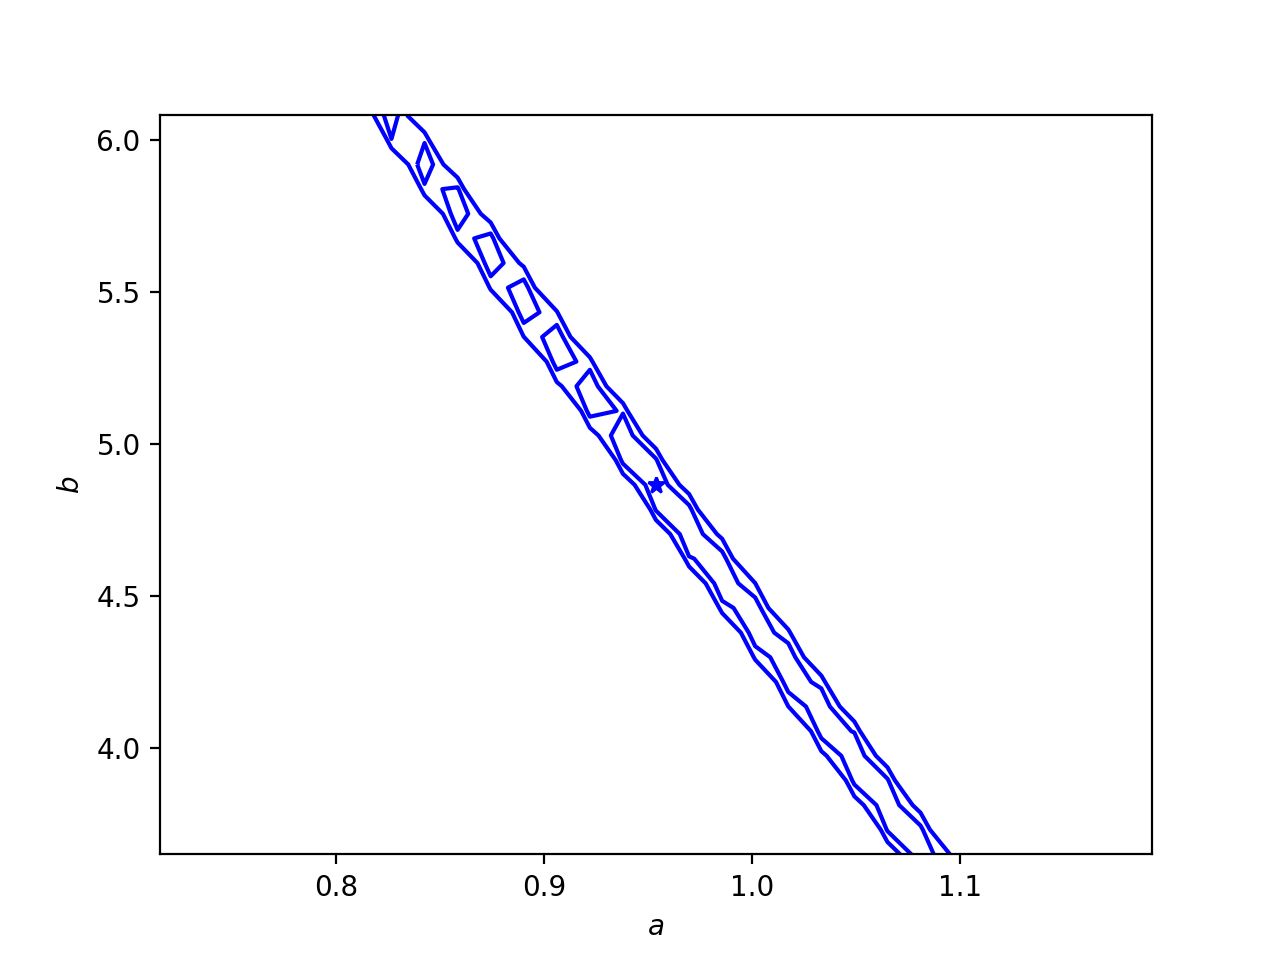

In [11]:
fig, ax = plt.subplots()

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$b$")

ndf = len(lM) - 2
sigma = np.sqrt(ndf)
ax.contour(xvals,yvals,pvals,levels=[1*sigma,2*sigma],colors="b")
ax.plot([res.x[0]],[res.x[1]],"b*")

<IPython.core.display.Javascript object>


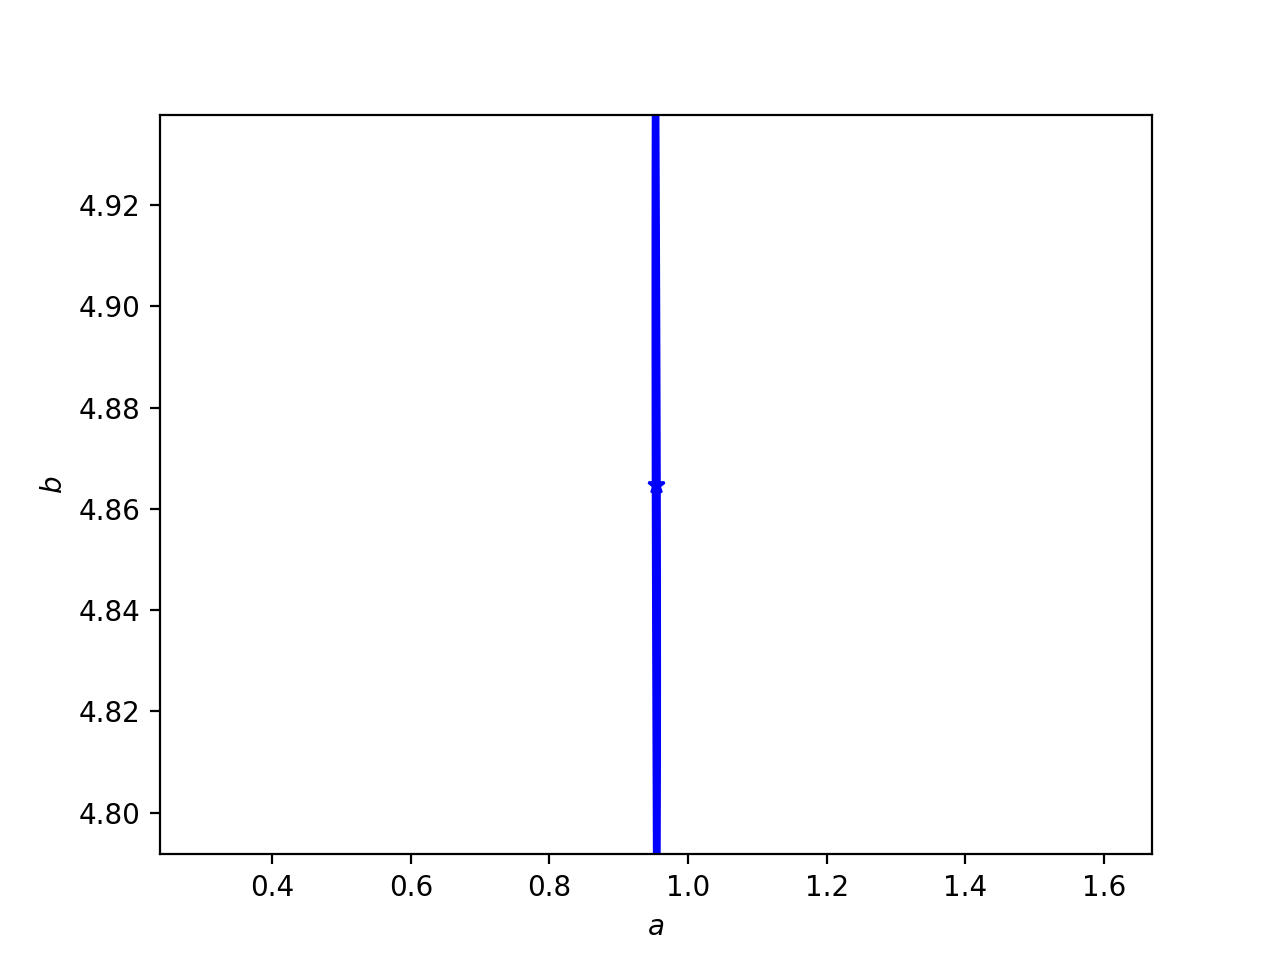

In [13]:
tv = np.copy(res.x)

for i1 in range(n+1):
    tv[1] = res.x[1]*(1+0.03/n*(i1-n/2))
    for i0 in range(n+1):
        tv[0] = res.x[0]*(1+1.5/n*(i0-n/2))
        xvals[i0,i1] = tv[0]
        yvals[i0,i1] = tv[1]
        pvals[i0,i1] = llfun(tv,loud=False) - res.fun
    #
#

fig, ax = plt.subplots()

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$b$")

ax.contour(xvals,yvals,pvals,levels=[1*sigma,2*sigma],colors="b")
ax.plot([res.x[0]],[res.x[1]],"b*")